In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
df = pd.read_csv(URL)

In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      238 non-null    int64  
 1   Unnamed: 0        238 non-null    int64  
 2   Manufacturer      238 non-null    object 
 3   Category          238 non-null    int64  
 4   GPU               238 non-null    int64  
 5   OS                238 non-null    int64  
 6   CPU_core          238 non-null    int64  
 7   Screen_Size_inch  238 non-null    float64
 8   CPU_frequency     238 non-null    float64
 9   RAM_GB            238 non-null    int64  
 10  Storage_GB_SSD    238 non-null    int64  
 11  Weight_pounds     238 non-null    float64
 12  Price             238 non-null    int64  
 13  Price-binned      238 non-null    object 
 14  Screen-Full_HD    238 non-null    int64  
 15  Screen-IPS_panel  238 non-null    int64  
dtypes: float64(3), int64(11), object(2)
memory u

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Select source and target variables
X = df[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category', 'Screen-Full_HD', 'Screen-IPS_panel', 'Weight_pounds']]
y = df['Price']

# Split the data into training and testing sets (optional, but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate MSE and R^2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R^2): {r2:.2f}")

# You can also print the model's coefficients if needed
print(f"\nModel Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_:.2f}")

Mean Squared Error (MSE): 168272.94
R-squared (R^2): 0.27

Model Coefficients: [ 1.01563833e+03  9.83485865e+01  3.44768607e-03  7.69900959e+01
 -5.00638328e+02  1.36287627e+02  1.54567935e+02  1.35595068e+01
 -1.35595068e+01 -9.54094812e+00]
Model Intercept: -766.18


Polynomial Regression Model Performance:

Order 2 Polynomial Regression:
  Mean Squared Error (MSE): 196263.56
  R-squared (R^2): 0.15



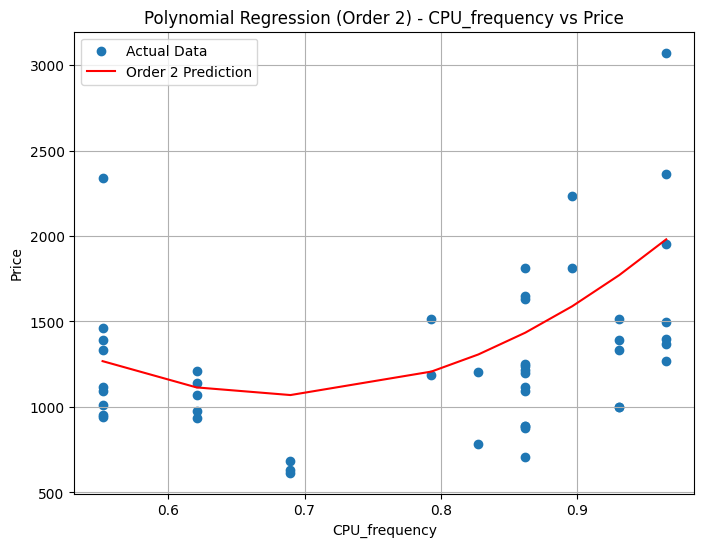

Order 3 Polynomial Regression:
  Mean Squared Error (MSE): 205918.03
  R-squared (R^2): 0.11



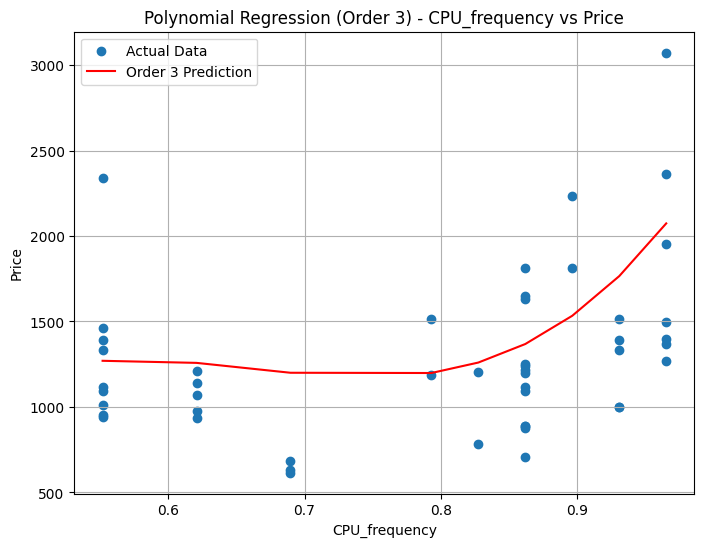

Order 5 Polynomial Regression:
  Mean Squared Error (MSE): 207335.70
  R-squared (R^2): 0.10



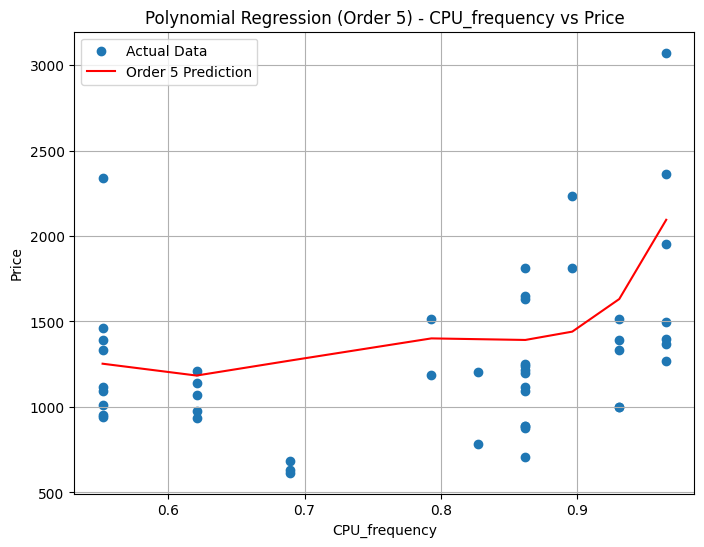

In [ ]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Define the source (X) and target (y) variables using the specified multiple features
X_multi = df[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category', 'Screen-Full_HD', 'Screen-IPS_panel', 'Weight_pounds']]
y_multi = df['Price']

# Split the data into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Create the pipeline
# Step 1: Standard Scaling of features
# Step 2: Generate Polynomial Features (e.g., degree 2)
# Step 3: Linear Regression model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)), # You can adjust the degree of polynomial features here
    ('model', LinearRegression())
])

# Train the pipeline on the training data
pipeline.fit(X_train_multi, y_train_multi)

# Make predictions on the test set
y_pred_pipeline = pipeline.predict(X_test_multi)

# Calculate MSE and R^2
mse_pipeline = mean_squared_error(y_test_multi, y_pred_pipeline)
r2_pipeline = r2_score(y_test_multi, y_pred_pipeline)

# Display the results
print(f"Pipeline Model Performance (Scaling + Polynomial Features + Linear Regression):\n")
print(f"Mean Squared Error (MSE): {mse_pipeline:.2f}")
print(f"R-squared (R^2): {r2_pipeline:.2f}")


Pipeline Model Performance (Scaling + Polynomial Features + Linear Regression):

Mean Squared Error (MSE): 176522.69
R-squared (R^2): 0.23


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the source (X) and target (y) variables using the specified multiple features
X_multi = df[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category', 'Screen-Full_HD', 'Screen-IPS_panel', 'Weight_pounds']]
y_multi = df['Price']

# Split the data into training and testing sets
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Create a pipeline with PolynomialFeatures, StandardScaler, and Ridge Regression
pipeline_gs = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)), # Polynomial features, excluding bias to avoid multicollinearity with intercept
    ('scaler', StandardScaler()),                    # Scale features
    ('ridge', Ridge())                               # Ridge Regression model
])

# Define the parameter grid for GridSearchCV
# We'll tune 'degree' for PolynomialFeatures and 'alpha' for Ridge
param_grid = {
    'poly__degree': [1, 2, 3],  # Test polynomial degrees 1, 2, and 3
    'ridge__alpha': np.logspace(-3, 3, 7) # Test alpha values from 0.001 to 1000
}

# Perform GridSearchCV with cross-validation
# cv=5 means 5-fold cross-validation
# scoring='neg_mean_squared_error' to optimize for lower MSE (GridSearchCV maximizes scores)
grid_search = GridSearchCV(pipeline_gs, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_gs, y_train_gs)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = -grid_search.best_score_ # Convert back to positive MSE

print(f"Best parameters found: {best_params}")
print(f"Best cross-validation MSE: {best_score:.2f}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred_gs = best_model.predict(X_test_gs)

mse_gs = mean_squared_error(y_test_gs, y_pred_gs)
r2_gs = r2_score(y_test_gs, y_pred_gs)

print(f"\nTest Set Performance of Best Model:")
print(f"Mean Squared Error (MSE): {mse_gs:.2f}")
print(f"R-squared (R^2): {r2_gs:.2f}")


Best parameters found: {'poly__degree': 2, 'ridge__alpha': 1.0}
Best cross-validation MSE: 126545.94

Test Set Performance of Best Model:
Mean Squared Error (MSE): 166865.50
R-squared (R^2): 0.28
